 PINN TRAINING WITH NORMATIVE DATA
Epochs: 8000 | λ_data = 1.0 | λ_physics = 1.0
Architecture: 1 → 64 → 64 → 1 (Tanh)
----------------------------------------------------------------------
Epoch [   1/8000] | Time:  0.0s | Total: 328.15237 | Data: 328.15152 | Physics: 0.00084
Epoch [1000/8000] | Time:  1.6s | Total: 0.71543 | Data: 0.01480 | Physics: 0.70064
Epoch [2000/8000] | Time:  1.5s | Total: 0.70248 | Data: 0.01345 | Physics: 0.68903
Epoch [3000/8000] | Time:  1.5s | Total: 0.69706 | Data: 0.01288 | Physics: 0.68418
Epoch [4000/8000] | Time:  1.5s | Total: 0.59066 | Data: 0.00995 | Physics: 0.58070
Epoch [5000/8000] | Time:  1.7s | Total: 0.37964 | Data: 0.00782 | Physics: 0.37182
Epoch [6000/8000] | Time:  1.5s | Total: 0.24026 | Data: 0.00883 | Physics: 0.23143
Epoch [7000/8000] | Time:  1.6s | Total: 0.17036 | Data: 0.00660 | Physics: 0.16376
Epoch [8000/8000] | Time:  1.5s | Total: 0.15976 | Data: 0.00339 | Physics: 0.15637

✓ Training completed in 12.44 seconds.

 SMART TRI

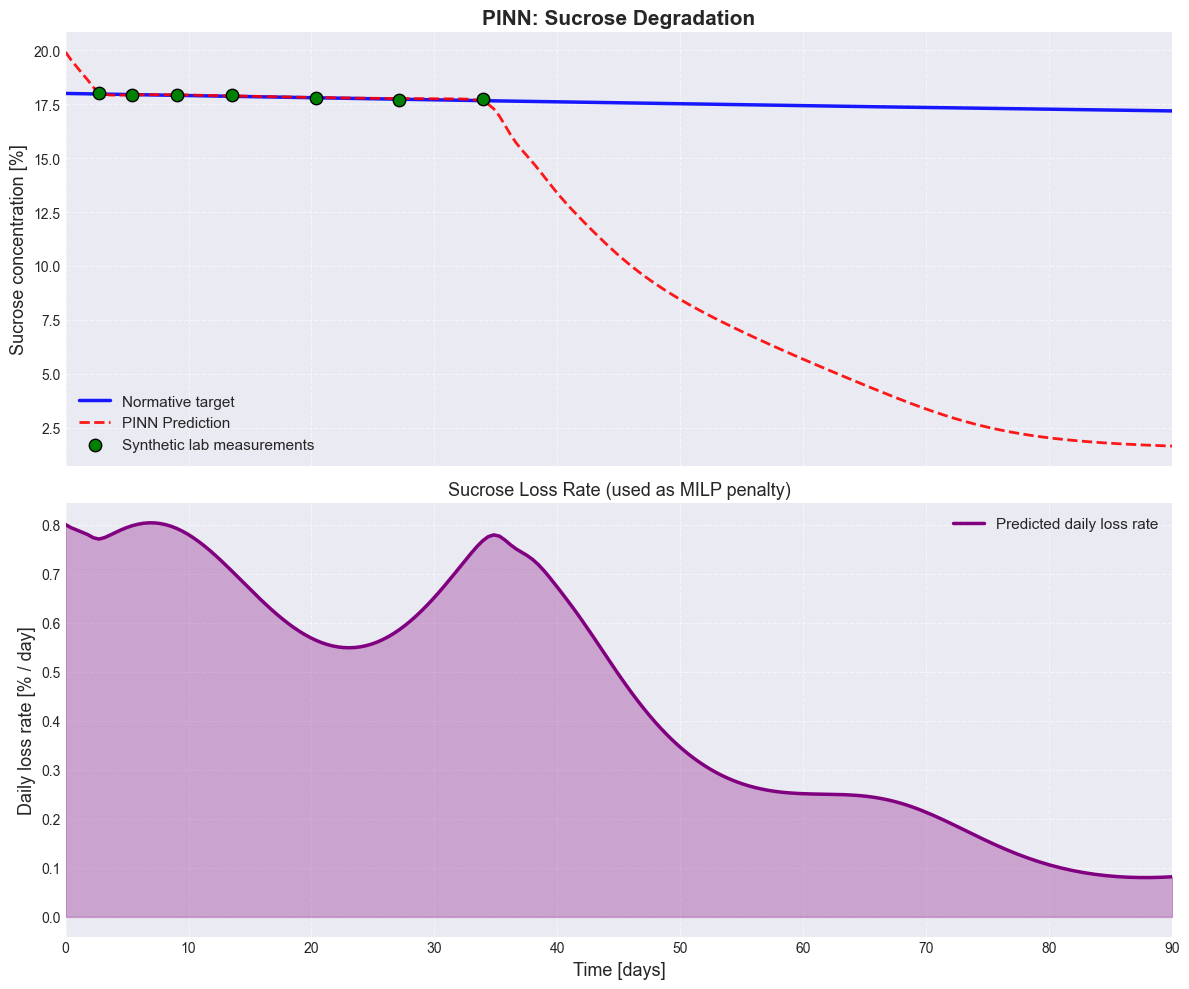

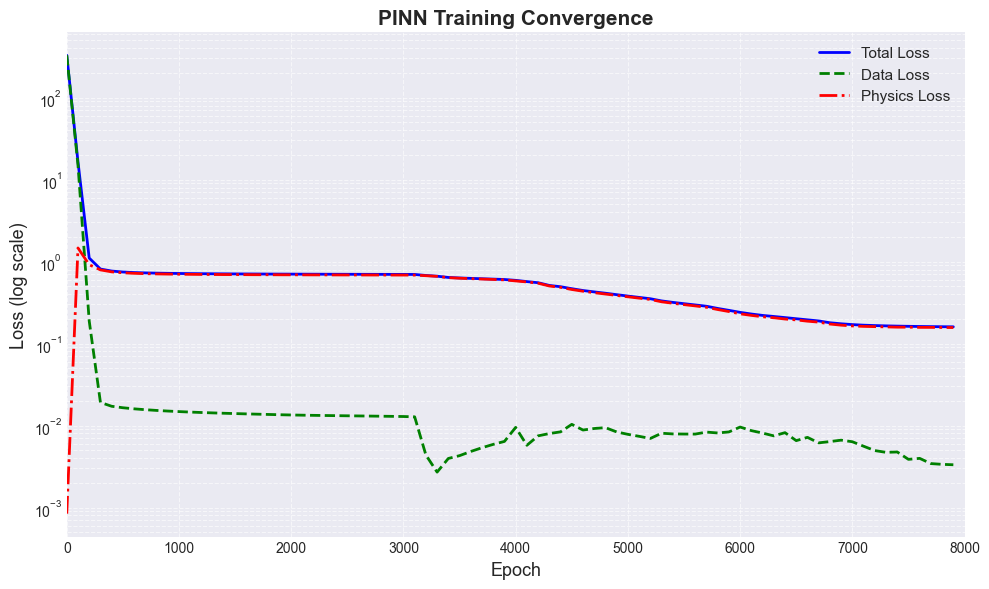

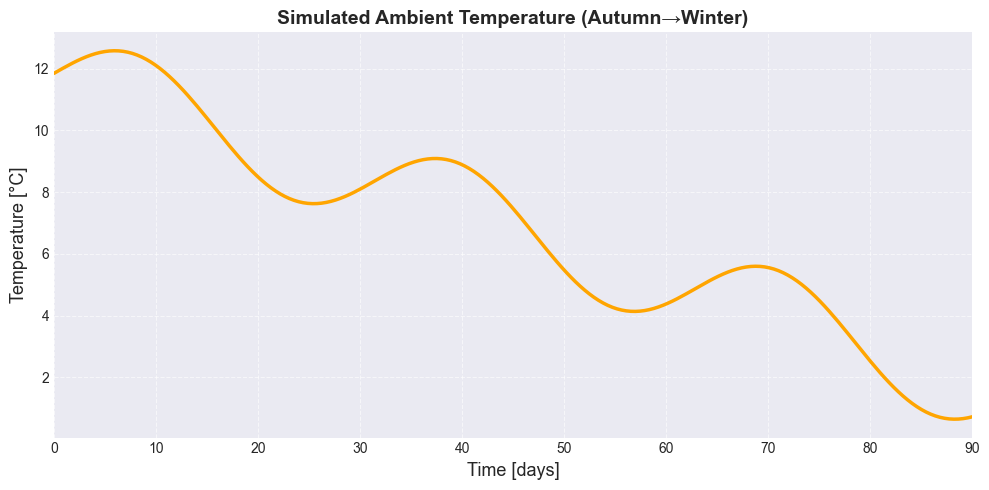

In [1]:
"""
PoC for PINN
Related Paper: Building Cyber-Physical Resilient Regional Supply Chains
Author: Corneliu Iatco
License: MIT

Trained on normative data from instruction
(https://meganorm.ru/mega_doc/norm/akt_forma/1/instruktsiya_po_normirovaniyu_poter_sveklomassy_i_sakhara_v.html)

Input data: CSV with monthly sugar losses for different groups and damage classes.
This script uses group=1, damage_class=1 (typical conditions).
"""

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import time
import json
import warnings
warnings.filterwarnings("ignore")

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# =============================================================================
# 1. LOAD NORMATIVE DATA FROM CSV
# =============================================================================
csv_data = "pinn_data.csv"

from io import StringIO
df_norm = pd.read_csv(csv_data)

# Select scenario: group=1 (moderate climate), damage_class=1 (up to 1% damaged)
df_sel = df_norm[(df_norm['group'] == 1) & (df_norm['damage_class'] == 1)].copy()
df_sel = df_sel.sort_values('month_index')

# Months and cumulative days mapping (approximate)
month_days = {'Sep': 30, 'Oct': 31, 'Nov': 30, 'Dec': 31, 'Jan': 31, 'Feb': 28, 'Mar': 31}
cum_days = [0]
for m in df_sel['month']:
    cum_days.append(cum_days[-1] + month_days[m])
cum_days = cum_days[:-1]  # start of each month (day 0, 30, 61, 91, ...)
df_sel['start_day'] = cum_days

# Create continuous time axis (0 to total days)
total_days = sum(month_days[m] for m in df_sel['month'])  # 212 days for Sep-Mar
days = 90  # focus on first 90 days of storage (Sep-Nov)
t_full = np.linspace(0, days, 200).reshape(-1, 1)

# Interpolate sugar loss rate (daily loss %) from monthly values onto t_full
t_loss = []
loss_rate = []
for idx, row in df_sel.iterrows():
    start = row['start_day']
    end = start + month_days[row['month']]
    t_loss.extend([start, end])
    loss_rate.extend([row['sugar_loss_percent_per_day'], row['sugar_loss_percent_per_day']])
t_loss = np.array(t_loss)
loss_rate = np.array(loss_rate)
f_loss = interp1d(t_loss, loss_rate, kind='previous', fill_value='extrapolate')

# Compute target sucrose concentration by integrating loss rate from initial 18%
initial_sucrose = 18.0
t_fine = np.linspace(0, days, 1000)
loss_fine = f_loss(t_fine)
S_fine = initial_sucrose - np.cumsum(loss_fine) * (t_fine[1]-t_fine[0])
S_true = np.interp(t_full.flatten(), t_fine, S_fine).reshape(-1, 1)

# Generate synthetic lab measurements (sporadic) at same days as original script
idx_lab = np.array([6, 12, 20, 30, 45, 60, 75])  # days
t_lab = t_full[idx_lab]
S_lab = S_true[idx_lab] + np.random.normal(0, 0.05, size=(len(idx_lab), 1))

# Convert to PyTorch tensors
t_tensor = torch.tensor(t_full, dtype=torch.float32, requires_grad=True)
t_lab_tensor = torch.tensor(t_lab, dtype=torch.float32)
S_lab_tensor = torch.tensor(S_lab, dtype=torch.float32)

# Temperature profile (same as before)
T_full = 285.0 - 10.0 * (t_full / days) + 1.5 * np.sin(0.2 * t_full)
T_tensor = torch.tensor(T_full, dtype=torch.float32)

# =============================================================================
# 2. PHYSICS CONSTANTS AND KINETICS
# =============================================================================
R = 8.314          # J/(mol*K)
Ea = 82000.0       # J/mol
A = 4.3e13         # pre-exponential factor
alpha = 0.0005     # microbiological acceleration (calibrated later)

def physics_loss(t, T, S, dS_dt):
    """Compute residual of ODE: dS/dt + A*exp(-Ea/(R T)) * S * (1 + alpha t^2) = 0"""
    t_detach = t.detach()
    decay_rate = A * torch.exp(-Ea / (R * T)) * S * (1.0 + alpha * (t_detach ** 2))
    residual = dS_dt + decay_rate
    return torch.mean(residual ** 2)

# =============================================================================
# 3. PINN ARCHITECTURE
# =============================================================================
class PINN_Sucrose(nn.Module):
    def __init__(self):
        super(PINN_Sucrose, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, t):
        return self.net(t)

model = PINN_Sucrose()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

# =============================================================================
# 4. TRAINING LOOP
# =============================================================================
epochs = 8000
lambda_data = 1.0
lambda_physics = 1.0

print("="*70)
print(" PINN TRAINING WITH NORMATIVE DATA")
print("="*70)
print(f"Epochs: {epochs} | λ_data = {lambda_data} | λ_physics = {lambda_physics}")
print("Architecture: 1 → 64 → 64 → 1 (Tanh)")
print("-"*70)

train_start = time.time()
epoch_timer = time.time()
loss_history = {"total": [], "data": [], "physics": []}

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Data loss at lab points
    S_pred_lab = model(t_lab_tensor)
    loss_data = torch.mean((S_pred_lab - S_lab_tensor)**2)
    
    # Physics loss at collocation points (all time points)
    S_pred_full = model(t_tensor)
    dS_dt = torch.autograd.grad(S_pred_full, t_tensor,
                                grad_outputs=torch.ones_like(S_pred_full),
                                create_graph=True)[0]
    loss_physics = physics_loss(t_tensor, T_tensor, S_pred_full, dS_dt)
    
    # Total loss
    loss_total = lambda_data * loss_data + lambda_physics * loss_physics
    loss_total.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        loss_history["total"].append(loss_total.item())
        loss_history["data"].append(loss_data.item())
        loss_history["physics"].append(loss_physics.item())
    
    if (epoch+1) % 1000 == 0 or epoch == 0:
        elapsed = time.time() - epoch_timer
        print(f"Epoch [{epoch+1:4d}/{epochs}] | Time: {elapsed:4.1f}s | "
              f"Total: {loss_total.item():.5f} | Data: {loss_data.item():.5f} | Physics: {loss_physics.item():.5f}")
        epoch_timer = time.time()

train_end = time.time()
print(f"\n✓ Training completed in {train_end - train_start:.2f} seconds.\n")

# =============================================================================
# 5. INFERENCE AND SMART TRIAGE
# =============================================================================
inference_start = time.time()
S_pred = model(t_tensor).detach().numpy()
inference_end = time.time()

# Daily loss rates (derived from predicted sucrose)
with torch.no_grad():
    S_all = model(t_tensor).numpy().flatten()
    T_full_flat = T_full.flatten()
    decay_rate = A * np.exp(-Ea / (R * T_full_flat)) * (1.0 + alpha * (t_full.flatten()**2))
    daily_loss_rate = decay_rate * S_all

# Month 1 vs Month 3 daily losses (same indices as before)
day_15_idx = 33
day_16_idx = 36
loss_early = S_pred[day_15_idx].item() - S_pred[day_16_idx].item()
day_80_idx = 177
day_81_idx = 180
loss_late = S_pred[day_80_idx].item() - S_pred[day_81_idx].item()

print("="*70)
print(" SMART TRIAGE RESULTS")
print("="*70)
print(f"Month 1 daily sucrose loss (respiration dominant):   {loss_early:.5f} %")
print(f"Month 3 daily sucrose loss (microbial active):       {loss_late:.5f} %")
print(f"Inference time: {inference_end - inference_start:.4f} sec")
print("-"*70)
if loss_late > loss_early:
    print("⚠ ALERT: Avalanche microbiological decay detected in Month 3!")
    print("⚠ Smart Triage shifts evacuation priority to older piles.")
else:
    print("ℹ Standard respiration dominates, no emergency rerouting.")
print("="*70)

# =============================================================================
# 6. SAVE MODEL AND PARAMETERS
# =============================================================================
torch.save(model.state_dict(), "pinn_sucrose_model.pth")
physics_params = {
    "A": A, "Ea": Ea, "R": R, "alpha": alpha,
    "initial_sucrose": initial_sucrose, "days": days
}
with open("pinn_physics_params.json", "w") as f:
    json.dump(physics_params, f, indent=4)

# Save predictions CSV
df_results = pd.DataFrame({
    "time_days": t_full.flatten(),
    "temperature_K": T_full.flatten(),
    "predicted_sucrose_percent": S_pred.flatten(),
    "daily_loss_rate_percent": daily_loss_rate
})
df_results.to_csv("pinn_predictions.csv", index=False)

# Also save the normative target for comparison
df_target = pd.DataFrame({
    "time_days": t_full.flatten(),
    "normative_sucrose_percent": S_true.flatten()
})
df_target.to_csv("normative_target.csv", index=False)

print("✓ Model saved to 'pinn_sucrose_model.pth'")
print("✓ Predictions saved to 'pinn_predictions.csv'")
print("✓ Normative target saved to 'normative_target.csv'")

# =============================================================================
# 7. GENERATE PLOTS
# =============================================================================
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(t_full, S_true, 'b-', linewidth=2.5, label='Normative target', alpha=0.9)
ax1.plot(t_full, S_pred, 'r--', linewidth=2, label='PINN Prediction', alpha=0.9)
ax1.scatter(t_lab, S_lab, color='green', s=80, marker='o', edgecolors='black',
            zorder=5, label='Synthetic lab measurements')
ax1.set_ylabel('Sucrose concentration [%]', fontsize=13)
ax1.set_title('PINN: Sucrose Degradation', fontsize=15, fontweight='bold')
ax1.legend(loc='best', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xlim(0, days)

ax2.plot(t_full, daily_loss_rate, 'purple', linewidth=2.5, label='Predicted daily loss rate')
ax2.fill_between(t_full.flatten(), 0, daily_loss_rate, alpha=0.3, color='purple')
ax2.set_xlabel('Time [days]', fontsize=13)
ax2.set_ylabel('Daily loss rate [% / day]', fontsize=13)
ax2.set_title('Sucrose Loss Rate (used as MILP penalty)', fontsize=13)
ax2.legend(loc='best', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(0, days)

plt.tight_layout()
plt.savefig("pinn_results.png", dpi=150, bbox_inches='tight')

# Loss history plot
fig2, ax = plt.subplots(figsize=(10, 6))
epochs_plot = np.arange(0, epochs+1, 100)[:len(loss_history["total"])]
ax.semilogy(epochs_plot, loss_history["total"], 'b-', linewidth=2, label='Total Loss')
ax.semilogy(epochs_plot, loss_history["data"], 'g--', linewidth=2, label='Data Loss')
ax.semilogy(epochs_plot, loss_history["physics"], 'r-.', linewidth=2, label='Physics Loss')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss (log scale)', fontsize=13)
ax.set_title('PINN Training Convergence', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.set_xlim(0, epochs)
plt.tight_layout()
plt.savefig("pinn_loss_curve.png", dpi=150, bbox_inches='tight')

# Temperature profile
fig3, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_full, T_full - 273.15, 'orange', linewidth=2.5)
ax.set_xlabel('Time [days]', fontsize=13)
ax.set_ylabel('Temperature [°C]', fontsize=13)
ax.set_title('Simulated Ambient Temperature (Autumn→Winter)', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(0, days)
plt.tight_layout()
plt.savefig("pinn_temperature.png", dpi=150, bbox_inches='tight')

print("\n" + "="*70)
print(" ALL FILES GENERATED SUCCESSFULLY")
print("="*70)
print("Output files:")
print("  - pinn_sucrose_model.pth       (PyTorch weights)")
print("  - pinn_physics_params.json     (physical constants)")
print("  - pinn_predictions.csv         (sucrose and loss rates)")
print("  - normative_target.csv         (ground truth from norms)")
print("  - pinn_results.png             (sucrose comparison + loss rate)")
print("  - pinn_loss_curve.png          (training loss)")
print("  - pinn_temperature.png         (temperature profile)")
print("="*70)
plt.show()